# Step 1 — Connected Load Estimation

**Purpose.** This notebook estimates the *connected load* of the site: the sum of the rated power of every appliance and miscellaneous load that could theoretically be switched on at once. This is the same quantity computed in **Annex-I** of `Base-Calculations-00.xlsx` ("Number of households and appliances breakdown list"), re-implemented here in Python so it can later be driven by an interactive web form (tabular editing, Excel upload) instead of spreadsheet cells.

**Method, in brief (from the workbook):**
- Households at the site are split into three socioeconomic categories — **A** (high income), **B** (medium/low income), **C** (low income) — each with its own fixed list of appliances and quantities per house.
- A separate **Miscellaneous** group covers shared/community loads: hospital, street lights, cold storage, school, and other infrastructure.
- Connected load of one appliance line = `Power (W) × Quantity × Number of households in that category` (for household appliances), or `Power (W) × Quantity` (for Misc. loads, which aren't per-household).
- **Total Connected Load = sum of every appliance/Misc. line.**

Every default number below (household counts, appliance lists, power ratings, quantities) is taken directly from Annex-I. All of it is meant to be editable later in the app — this notebook builds the calculation as plain, well-commented Python functions operating on a pandas DataFrame, so swapping in user-edited values (via a table or an uploaded Excel file) is just replacing the DataFrame's contents, not changing the logic.

**Reference:** see `docs/Workbook-Methodology-Reference.md` §2 for the full Annex-I formula breakdown this notebook is built from.

## 1.1 Setup

Import the libraries we need for this notebook:
- `pandas` / `numpy` — tabular data and numeric operations
- `pathlib` — file paths that work the same on Windows and the cloud sandbox
- `openpyxl` — used indirectly by pandas to read/write `.xlsx` files (the Excel upload/download workflow)

We also define `PROJECT_ROOT` and a `data/` folder path where the default appliance/household tables will live as plain CSV files — this is the single source of default data that both this notebook and (later) the Streamlit app will read from, so the two never drift apart.

In [1]:
import pandas as pd  # pandas: the library for tabular data (DataFrames) used throughout this project
import numpy as np  # numpy: numerical operations (arrays, NaN, math)
from pathlib import Path  # Path: OS-independent file path handling (works the same on Windows and Linux)

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()  # find the project's root folder regardless of where the notebook is run from
DATA_DIR = PROJECT_ROOT / "data"  # the shared "data/" folder path used by every notebook and the app
DATA_DIR.mkdir(exist_ok=True)  # mkdir(): create data/ if it doesn't already exist (no error if it does)

print("pandas:", pd.__version__)  # confirm which pandas version is active
print("numpy:", np.__version__)  # confirm which numpy version is active
print("Project root:", PROJECT_ROOT.resolve())  # show the resolved absolute path, for sanity-checking
print("Data dir:", DATA_DIR.resolve())  # show the resolved absolute path, for sanity-checking

pandas: 3.0.5
numpy: 2.4.6
Project root: /home/claude/rural-electrification
Data dir: /home/claude/rural-electrification/data


## 1.2 Default household & appliance data (from Annex-I)

The site's households are split into **three socioeconomic categories**, each with its own fixed appliance list and quantities. Separately, **Miscellaneous** covers shared/community loads that aren't per-household.

We store three small tables — this is deliberately *not* one giant table, because household categories and Misc. loads have different shapes (Misc. loads aren't multiplied by a household count):

1. **`household_categories`** — how many households are in each category, and what % of the total that represents.
2. **`appliances`** — one row per (category, appliance): its rated power and how many of that appliance a typical house in that category owns.
3. **`misc_loads`** — one row per shared/community load: its rated power and how many units exist at the site.

All numbers below are the workbook's defaults (Annex-I). Every one of these is meant to be user-editable later — changing a number here, or replacing these DataFrames with an uploaded Excel file, is all downstream code needs; no formulas change.

**Note on Category C:** the workbook only models LED Light and Ceiling Fan for Category C (the smallest, lowest-income dwelling type — no iron, fridge, or washing machine assumed) — this isn't an omission, it's a deliberate income-based assumption carried over from the source file.

In [2]:
# --- 1. Household categories: count and % split of the total 1,480 households ---
household_categories = pd.DataFrame([  # pd.DataFrame(): build a table from a list of row-dictionaries, one dict per category
    {"category": "A", "label": "High income (10%) — 2BR, 110 sqm",       "pct_split": 10, "household_count": 150},
    {"category": "B", "label": "Medium/low income (50%) — 1BR, 70 sqm",  "pct_split": 50, "household_count": 740},
    {"category": "C", "label": "Low income (40%) — 1BR, 50 sqm",         "pct_split": 40, "household_count": 590},
])

assert household_categories["household_count"].sum() == 1480, "Household categories should sum to the site total (1,480)"  # assert: stop with an error message if this check ever fails
household_categories  # display the table (the last bare line in a cell auto-displays in Jupyter)

,category,label,pct_split,household_count
0,A,"High income (10%) — 2BR, 110 sqm",10,150
1,B,"Medium/low income (50%) — 1BR, 70 sqm",50,740
2,C,"Low income (40%) — 1BR, 50 sqm",40,590


In [3]:
# --- 2. Appliances per household, by category ---
# power_w: rated power of one unit (W)
# qty_per_house: how many of this appliance a typical house in this category owns

appliances = pd.DataFrame([  # pd.DataFrame(): build the appliance table from a list of row-dictionaries, one dict per appliance line
    # Category A (high income) — 6 appliance types
    {"category": "A", "appliance": "LED Light",       "power_w": 18,  "qty_per_house": 5, "comment": ""},
    {"category": "A", "appliance": "Ceiling Fan",      "power_w": 50,  "qty_per_house": 3, "comment": ""},
    {"category": "A", "appliance": "Television",       "power_w": 60,  "qty_per_house": 1, "comment": ""},
    {"category": "A", "appliance": "Iron",              "power_w": 800, "qty_per_house": 1, "comment": "Assuming daily use for simplicity"},
    {"category": "A", "appliance": "Refrigerator",      "power_w": 800, "qty_per_house": 1, "comment": "800 W = surge load; running load ~200 W (assumed)"},
    {"category": "A", "appliance": "Washing Machine",   "power_w": 350, "qty_per_house": 1, "comment": "Assuming daily use for simplicity (actual: 2 days/week)"},

    # Category B (medium/low income) — 5 appliance types (no washing machine)
    {"category": "B", "appliance": "LED Light",       "power_w": 18,  "qty_per_house": 4, "comment": ""},
    {"category": "B", "appliance": "Ceiling Fan",      "power_w": 50,  "qty_per_house": 2, "comment": ""},
    {"category": "B", "appliance": "Television",       "power_w": 60,  "qty_per_house": 1, "comment": ""},
    {"category": "B", "appliance": "Iron",              "power_w": 800, "qty_per_house": 1, "comment": "Assuming daily use for simplicity"},
    {"category": "B", "appliance": "Refrigerator",      "power_w": 800, "qty_per_house": 1, "comment": ""},

    # Category C (low income) — only 2 appliance types (no iron/fridge/washing machine)
    {"category": "C", "appliance": "LED Light",       "power_w": 18,  "qty_per_house": 2, "comment": ""},
    {"category": "C", "appliance": "Ceiling Fan",      "power_w": 50,  "qty_per_house": 1, "comment": ""},

    # "Others" — a placeholder row per category so the user can add an appliance that
    # isn't in the default list above, without editing the table's structure. Starts
    # at 0 W (no load) until edited: set power_w to the new appliance's rating and
    # qty_per_house to how many a typical house in that category owns.
    {"category": "A", "appliance": "Others",           "power_w": 0,   "qty_per_house": 1, "comment": "Placeholder for an extra appliance — edit power (W) and qty per house"},
    {"category": "B", "appliance": "Others",           "power_w": 0,   "qty_per_house": 1, "comment": "Placeholder for an extra appliance — edit power (W) and qty per house"},
    {"category": "C", "appliance": "Others",           "power_w": 0,   "qty_per_house": 1, "comment": "Placeholder for an extra appliance — edit power (W) and qty per house"},
])
appliances  # display the table

,category,appliance,power_w,qty_per_house,comment
0,A,LED Light,18,5,
1,A,Ceiling Fan,50,3,
2,A,Television,60,1,
3,A,Iron,800,1,Assuming daily use for simplicity
4,A,Refrigerator,800,1,800 W = surge load; running load ~200 W (assumed)
5,A,Washing Machine,350,1,Assuming daily use for simplicity (actual: 2 d...
6,B,LED Light,18,4,
7,B,Ceiling Fan,50,2,
8,B,Television,60,1,
9,B,Iron,800,1,Assuming daily use for simplicity


In [4]:
# --- 3. Miscellaneous / shared community loads (not scaled by household count) ---
# power_w: rated power of one unit (W)     qty: how many units exist at the site

# The "School" load is itself computed from other appliances' power ratings
# (10 classrooms etc.: ~20 LED lights + 14 ceiling fans + 20 computers @ 200 W + 1 fridge),
# reproducing Annex-I's formula `=20*C7+14*C8+20*200+C11` exactly:
led_w = 18       # assign: LED rating reused from the Category A/B/C appliance list, for the School formula below
fan_w = 50       # assign: ceiling fan rating reused from the Category A/B/C appliance list
fridge_w = 800   # assign: fridge rating reused from Category A/B
school_power_w = 20 * led_w + 14 * fan_w + 20 * 200 + fridge_w  # compute: School's total power = 20 lights + 14 fans + 20 computers (200 W each) + 1 fridge
print(f"Computed School connected power: {school_power_w} W  (workbook value: 5,860 W)")  # print: show the computed value next to the known workbook value, to eyeball a match

misc_loads = pd.DataFrame([  # pd.DataFrame(): build the misc/community load table from a list of row-dictionaries
    {"appliance": "Hospital",      "power_w": 2000,           "qty": 1,  "comment": "~40 kWh/day small hospital -> ~2 kW constant load assumed; 1 hospital in area"},
    {"appliance": "Street Light",  "power_w": 60,             "qty": 50, "comment": "50 lights assumed for a 0.65 sq.km area (perimeter, internal roads, population)"},
    {"appliance": "Cold Storage",  "power_w": 10500,          "qty": 5,  "comment": "28A/380V max current; constant load assumed (multiple compressors stagger surge)"},
    {"appliance": "School",        "power_w": school_power_w, "qty": 1,  "comment": "10 classrooms + staff/principal/admin rooms + 4 toilets + canteen: ~20 lights, 14 fans, 20 computers (200 W), 1 fridge"},
    {"appliance": "Others",        "power_w": 4000,           "qty": 1,  "comment": "Pumps, offices, shops, etc. — assumed 2x the hospital load"},
])
misc_loads  # display the table

Computed School connected power: 5860 W  (workbook value: 5,860 W)


,appliance,power_w,qty,comment
0,Hospital,2000,1,~40 kWh/day small hospital -> ~2 kW constant l...
1,Street Light,60,50,50 lights assumed for a 0.65 sq.km area (perim...
2,Cold Storage,10500,5,28A/380V max current; constant load assumed (m...
3,School,5860,1,10 classrooms + staff/principal/admin rooms + ...
4,Others,4000,1,"Pumps, offices, shops, etc. — assumed 2x the h..."


### Saving these as the default data files

We save all three tables as CSV files under `data/`. These become the single source of default values: the Streamlit app will load them the same way this notebook does, and a user's edits (typed into a table, or an uploaded Excel file) simply replace these DataFrames in memory — none of the calculation logic (built in the next section) needs to know or care where the numbers came from.

In [5]:
household_categories.to_csv(DATA_DIR / "default_household_categories.csv", index=False)  # to_csv(): save this table to disk as a plain CSV file (index=False = don't write the row-number column)
appliances.to_csv(DATA_DIR / "default_appliances.csv", index=False)
misc_loads.to_csv(DATA_DIR / "default_misc_loads.csv", index=False)

print("Saved default data files to:", DATA_DIR.resolve())  # print: confirm where the files were written
for f in ["default_household_categories.csv", "default_appliances.csv", "default_misc_loads.csv"]:  # for loop: iterate over the three filenames just written
    print(" -", f)  # print: list each filename

Saved default data files to: /home/claude/rural-electrification/data
 - default_household_categories.csv
 - default_appliances.csv
 - default_misc_loads.csv


## 1.3 Connected load calculation

This reproduces Annex-I's core formula:

- **Household appliance line:** `Connected Load (W) = Power (W) × Qty per house × Number of households in that category`
  (Annex-I: `E7 = C7*D7*$K$7`, etc.)
- **Misc./community load line:** `Connected Load (W) = Power (W) × Qty`
  (Annex-I: `E23 = C23*D23`, etc. — not scaled by household count, since these are shared site-wide facilities, not per-house.)
- **Total Connected Load = sum of every line**, both household and Misc.

We write this as one small function, `compute_connected_load()`, that takes the three tables from §1.2 and returns everything at three levels of detail: every individual line, a per-category subtotal, and the grand total — so later, editing the input tables (by hand or via an uploaded Excel file) is the *only* thing that changes; this function stays the same.

In [6]:
def compute_connected_load(appliances_df: pd.DataFrame,
                            household_categories_df: pd.DataFrame,
                            misc_loads_df: pd.DataFrame) -> dict:
    """
    Compute connected load at three levels of detail from the three input tables.

    Returns a dict with:
      - "lines"        : every appliance/misc line with its own Connected Load (W)
      - "by_category"  : subtotal per category (A, B, C, Misc)
      - "total_w"      : grand total connected load, in W
    """
    # --- Household appliance lines: Power x Qty per house x Household count ---
    lines_hh = appliances_df.merge(  # merge(): join the appliances table to household_categories on "category", to pull in each category's household_count
        household_categories_df[["category", "household_count"]],
        on="category", how="left"
    )
    lines_hh["connected_load_w"] = (  # compute: Power (W) x Qty per house x Household count = connected load of this appliance line, across all households in that category
        lines_hh["power_w"] * lines_hh["qty_per_house"] * lines_hh["household_count"]
    )
    lines_hh = lines_hh[["category", "appliance", "power_w", "qty_per_house",  # select: keep only the columns we need, in a consistent order (so it lines up with lines_misc below)
                          "household_count", "connected_load_w", "comment"]]

    # --- Misc./community lines: Power x Qty (not scaled by household count) ---
    lines_misc = misc_loads_df.copy()  # copy(): work on a copy so we don't modify the original misc_loads table
    lines_misc["connected_load_w"] = lines_misc["power_w"] * lines_misc["qty"]  # compute: Power (W) x Qty = connected load of this misc line (no household scaling)
    lines_misc.insert(0, "category", "Misc")  # insert(): add a "category" column (all "Misc") as the first column, so this table has the same shape as lines_hh
    lines_misc = lines_misc.rename(columns={"qty": "qty_per_house"})  # rename(): rename "qty" to "qty_per_house" so the column names match lines_hh for concatenation
    lines_misc["household_count"] = np.nan  # assign: household_count doesn't apply to Misc lines, so mark it "not a number"
    lines_misc = lines_misc[["category", "appliance", "power_w", "qty_per_house",
                              "household_count", "connected_load_w", "comment"]]

    lines = pd.concat([lines_hh, lines_misc], ignore_index=True)  # concat(): stack the household and misc line tables into one combined table

    by_category = (
        lines.groupby("category", sort=False)["connected_load_w"]  # groupby(): group all lines by category (A/B/C/Misc), keeping the original order
        .sum()  # sum(): total connected_load_w within each category group
        .reset_index()  # reset_index(): turn the grouped result back into a normal table with "category" as a column
        .rename(columns={"connected_load_w": "connected_load_w_subtotal"})  # rename(): give the summed column a clearer name
    )

    total_w = lines["connected_load_w"].sum()  # sum(): grand total connected load across every line, in W

    return {"lines": lines, "by_category": by_category, "total_w": total_w}


result = compute_connected_load(appliances, household_categories, misc_loads)  # call the function on our default tables
result["lines"]  # display the full line-by-line table

,category,appliance,power_w,qty_per_house,household_count,connected_load_w,comment
0,A,LED Light,18,5,150.0,13500,
1,A,Ceiling Fan,50,3,150.0,22500,
2,A,Television,60,1,150.0,9000,
3,A,Iron,800,1,150.0,120000,Assuming daily use for simplicity
4,A,Refrigerator,800,1,150.0,120000,800 W = surge load; running load ~200 W (assumed)
5,A,Washing Machine,350,1,150.0,52500,Assuming daily use for simplicity (actual: 2 d...
6,B,LED Light,18,4,740.0,53280,
7,B,Ceiling Fan,50,2,740.0,74000,
8,B,Television,60,1,740.0,44400,
9,B,Iron,800,1,740.0,592000,Assuming daily use for simplicity


In [7]:
result["by_category"]  # display the per-category subtotal table

,category,connected_load_w_subtotal
0,A,337500
1,B,1355680
2,C,50740
3,Misc,67360


In [8]:
total_w = result["total_w"]  # pull the grand total (W) out of the result dict for convenience
print(f"Total Connected Load: {total_w:,.0f} W")  # print: show the total in Watts, comma-separated
print(f"                     = {total_w/1000:,.2f} kW")  # print: same total converted to kW
print(f"                     = {total_w/1_000_000:,.5f} MW")  # print: same total converted to MW

# Sanity check against the workbook's known answer (Annex-I row 28): 1.81128 MW.
# The new "Others" placeholder rows default to 0 W, so this total should still match exactly.
workbook_total_mw = 1.81128  # the known correct answer, taken directly from the source Excel file
computed_total_mw = total_w / 1_000_000  # convert our computed total to MW for comparison
assert abs(computed_total_mw - workbook_total_mw) < 1e-6, \
    f"Mismatch vs workbook: computed {computed_total_mw} MW, expected {workbook_total_mw} MW"  # assert: stop with an error if our number doesn't match the workbook's (within floating-point tolerance)
print(f"\n✓ Matches workbook value of {workbook_total_mw} MW")  # print: confirm the match

Total Connected Load: 1,811,280 W
                     = 1,811.28 kW
                     = 1.81128 MW

✓ Matches workbook value of 1.81128 MW


In [9]:
# Save the connected-load results, so later steps (Step 6's summary table) don't need to recompute this from scratch.
connected_load_results = pd.DataFrame([
    {"result": "total_connected_load_w", "value": total_w, "unit": "W"},
    {"result": "total_connected_load_mw", "value": total_w / 1_000_000, "unit": "MW"},
])
connected_load_results.to_csv(DATA_DIR / "connected_load_results.csv", index=False)  # to_csv(): save the summary result
result["by_category"].to_csv(DATA_DIR / "connected_load_by_category.csv", index=False)  # also save the per-category breakdown
print("Saved to:", (DATA_DIR / "connected_load_results.csv").resolve())

Saved to: /home/claude/rural-electrification/data/connected_load_results.csv


## 1.4 Excel download / edit / re-upload workflow

Per the brief: most inputs are pre-filled, but the user should be able to download the current table as a formatted `.xlsx`, edit it in Excel (change appliance quantities, power ratings, household counts, add a real "Others" appliance, etc.), and re-upload it to replace the defaults.

Two functions:

- **`export_appliance_template()`** — writes the three tables (`household_categories`, `appliances`, `misc_loads`) to one Excel workbook, one sheet each, with a short "Instructions" sheet in front. This is exactly what the app's "Download template" button will call.
- **`import_appliance_template()`** — reads a workbook in that same shape back into the three DataFrames, and **validates** it (required columns present, categories are A/B/C, no negative numbers) before handing it back — so a malformed re-upload fails with a clear message instead of silently producing wrong load numbers.

In [10]:
def export_appliance_template(household_categories_df: pd.DataFrame,
                               appliances_df: pd.DataFrame,
                               misc_loads_df: pd.DataFrame,
                               output_path) -> None:
    """Write the three input tables to one formatted .xlsx workbook for the user to download and edit."""
    with pd.ExcelWriter(output_path, engine="xlsxwriter") as writer:  # ExcelWriter(): open a new .xlsx file for writing multiple sheets, using the xlsxwriter engine (needed for formatting)
        workbook = writer.book  # .book: the underlying xlsxwriter Workbook object, needed to define cell formats
        header_fmt = workbook.add_format({  # add_format(): define a reusable header style (bold, blue background, white text, bordered)
            "bold": True, "bg_color": "#2a78d6", "font_color": "white", "border": 1
        })

        instructions = pd.DataFrame({  # pd.DataFrame(): build a one-column table of plain-text instructions for the "Instructions" sheet
            "Instructions": [
                "Edit any value in the 'Household Categories', 'Appliances', or 'Misc Loads' sheets.",
                "Do not rename columns or sheets — the app matches them by name on re-upload.",
                "'category' must be A, B, or C on the Appliances sheet.",
                "To add a new appliance, edit one of the existing 'Others' rows (set its power_w and qty_per_house).",
                "Save the file, then re-upload it in the app to use these values instead of the defaults.",
            ]
        })
        instructions.to_excel(writer, sheet_name="Instructions", index=False)  # to_excel(): write this table to its own sheet in the open workbook

        household_categories_df.to_excel(writer, sheet_name="Household Categories", index=False)
        appliances_df.to_excel(writer, sheet_name="Appliances", index=False)
        misc_loads_df.to_excel(writer, sheet_name="Misc Loads", index=False)

        # Bold headers + sensible column widths on every sheet
        for sheet_name, df in [("Instructions", instructions),  # for loop: apply the same header formatting to every sheet we just wrote
                                ("Household Categories", household_categories_df),
                                ("Appliances", appliances_df),
                                ("Misc Loads", misc_loads_df)]:
            ws = writer.sheets[sheet_name]  # look up the xlsxwriter worksheet object for this sheet
            for col_idx, col_name in enumerate(df.columns):  # enumerate(): loop over each column together with its position number
                ws.write(0, col_idx, col_name, header_fmt)  # write(): re-write the header cell (row 0) using the bold header format
                width = max(12, min(45, int(df[col_name].astype(str).str.len().max() or 10) + 2))  # compute a column width from the longest value in that column, clamped between 12 and 45
                ws.set_column(col_idx, col_idx, width)  # set_column(): apply that width to the column


def import_appliance_template(input_path) -> dict:
    """
    Read a workbook in the export_appliance_template() shape back into the three tables.
    Returns {"household_categories": df, "appliances": df, "misc_loads": df, "errors": [list of str]}.
    If "errors" is non-empty, the data should NOT be used — surface the errors to the user instead.
    """
    errors = []  # collect any validation problems found, as plain text messages
    sheets = pd.read_excel(input_path, sheet_name=None)  # read_excel(): read every sheet in the workbook at once, as a dict of {sheet_name: DataFrame}

    required_sheets = {"Household Categories": ["category", "label", "pct_split", "household_count"],  # the sheets and columns we require to exist, for validation
                        "Appliances": ["category", "appliance", "power_w", "qty_per_house"],
                        "Misc Loads": ["appliance", "power_w", "qty"]}

    for sheet_name, required_cols in required_sheets.items():  # for loop: check each required sheet is present and has all its required columns
        if sheet_name not in sheets:
            errors.append(f"Missing required sheet: '{sheet_name}'")
            continue
        missing_cols = [c for c in required_cols if c not in sheets[sheet_name].columns]  # list comprehension: find which required columns are missing from this sheet
        if missing_cols:
            errors.append(f"Sheet '{sheet_name}' is missing column(s): {missing_cols}")

    if not errors:  # only run the deeper value checks if the sheets/columns are all present
        hh = sheets["Household Categories"]
        appl = sheets["Appliances"]
        misc = sheets["Misc Loads"]

        bad_categories = set(appl["category"].unique()) - {"A", "B", "C"}  # set difference: find any category value that isn't A, B, or C
        if bad_categories:
            errors.append(f"Appliances sheet has invalid category value(s): {sorted(bad_categories)} (must be A, B, or C)")

        for df, cols, name in [(hh, ["household_count", "pct_split"], "Household Categories"),  # for loop: check that no numeric column has a negative value, across all three sheets
                                (appl, ["power_w", "qty_per_house"], "Appliances"),
                                (misc, ["power_w", "qty"], "Misc Loads")]:
            for col in cols:
                if (df[col] < 0).any():  # .any(): True if at least one row in this column is negative
                    errors.append(f"Sheet '{name}' column '{col}' has negative value(s), which isn't physically valid")

    if errors:  # if any problems were found, return them instead of the data — caller must check "errors" before using the tables
        return {"household_categories": None, "appliances": None, "misc_loads": None, "errors": errors}

    return {"household_categories": sheets["Household Categories"],  # no problems found — return the three validated tables
            "appliances": sheets["Appliances"],
            "misc_loads": sheets["Misc Loads"],
            "errors": []}

### Round-trip test

Export the current default tables, then immediately re-import them, and confirm the connected-load total still comes out to 1.81128 MW — proving the export/import pair is lossless and the validation logic doesn't false-positive on well-formed data.

In [11]:
template_path = DATA_DIR / "Connected_Load_Input_Template.xlsx"  # the file path to write the template to
export_appliance_template(household_categories, appliances, misc_loads, template_path)  # call: write the current default tables out as a formatted Excel template
print("Exported template to:", template_path.resolve())  # print: confirm where it was written

reimported = import_appliance_template(template_path)  # call: immediately read that same file back in, to test the round trip
if reimported["errors"]:  # check: show errors instead of proceeding, if the re-import found any problems
    print("Validation errors:", reimported["errors"])
else:
    reimport_result = compute_connected_load(  # call: recompute connected load from the re-imported tables
        reimported["appliances"], reimported["household_categories"], reimported["misc_loads"]
    )
    reimport_total_mw = reimport_result["total_w"] / 1_000_000  # convert to MW for comparison
    print(f"Re-imported total connected load: {reimport_total_mw:.5f} MW")  # print: show the recomputed total
    assert abs(reimport_total_mw - 1.81128) < 1e-6, "Round-trip mismatch!"  # assert: confirm it still matches the original 1.81128 MW
    print("✓ Round-trip export -> re-import -> recompute matches the original total")

Exported template to: /home/claude/rural-electrification/data/Connected_Load_Input_Template.xlsx


Re-imported total connected load: 1.81128 MW
✓ Round-trip export -> re-import -> recompute matches the original total


### Validation check (deliberately broken input)

A quick negative test: feed the importer an appliances table with an invalid category, and confirm it's caught with a clear message rather than silently producing a wrong number.

In [12]:
bad_appliances = appliances.copy()  # copy(): work on a copy so we don't corrupt the real appliances table
bad_appliances.loc[0, "category"] = "Z"  # .loc[]: deliberately set an invalid category value, to test that validation catches it
bad_path = DATA_DIR / "_test_bad_template.xlsx"  # a throwaway file path used only for this test
export_appliance_template(household_categories, bad_appliances, misc_loads, bad_path)  # call: write the deliberately-broken table out to a test file

bad_result = import_appliance_template(bad_path)  # call: try to re-import the broken file
print("Errors detected:", bad_result["errors"])  # print: show what validation caught
assert bad_result["errors"], "Expected validation to catch the invalid category but it didn't!"  # assert: fail loudly if validation somehow let the bad value through
print("✓ Validation correctly rejected the malformed file")

bad_path.unlink()  # unlink(): delete the throwaway test file, since it was only needed for this check

Errors detected: ["Appliances sheet has invalid category value(s): ['Z'] (must be A, B, or C)"]
✓ Validation correctly rejected the malformed file


## 1.5 Visualizing the connected load breakdown

Two views of the same numbers:

1. **Connected load by category** — how much of the 1.81 MW comes from Category A households, B, C, or shared Misc. loads.
2. **Top individual load contributors** — which specific appliance/misc lines (e.g. Cold Storage, Category B lighting) actually drive that total, colored by which category they belong to.

Each category (A/B/C/Misc) keeps the same color across both charts and every later chart in this project, using a fixed, colorblind-safe palette rather than picking colors freely per chart.

In [13]:
import matplotlib.pyplot as plt  # matplotlib.pyplot: the plotting library used for the charts below
# inline: force charts to render directly in the notebook output instead of a separate GUI window — avoids a chart
# cell hanging forever locally if matplotlib happens to default to an interactive backend on your machine
%matplotlib inline

# Fixed category -> color mapping, reused across every chart in this project.
CATEGORY_COLORS = {  # dict: map each category to a fixed hex color, so the same category always gets the same color in every chart
    "A": "#2a78d6",     # blue
    "B": "#eb6834",     # orange
    "C": "#1baf7a",     # aqua
    "Misc": "#eda100",  # yellow
}
GRIDLINE = "#e1e0d9"  # the hairline gridline color used behind the bars
AXIS_INK = "#c3c2b7"  # the color for axis border lines
TEXT_PRIMARY = "#0b0b0b"  # the main text color (titles, data labels)
TEXT_MUTED = "#898781"  # the muted color for axis tick labels

plt.rcParams["font.family"] = "sans-serif"  # rcParams: set matplotlib's global default font family for every chart in this notebook
plt.rcParams["axes.edgecolor"] = AXIS_INK  # set the default axis border color
plt.rcParams["text.color"] = TEXT_PRIMARY  # set the default text color
plt.rcParams["axes.labelcolor"] = TEXT_PRIMARY  # set the default axis-label color
plt.rcParams["xtick.color"] = TEXT_MUTED  # set the default x-axis tick label color
plt.rcParams["ytick.color"] = TEXT_MUTED  # set the default y-axis tick label color

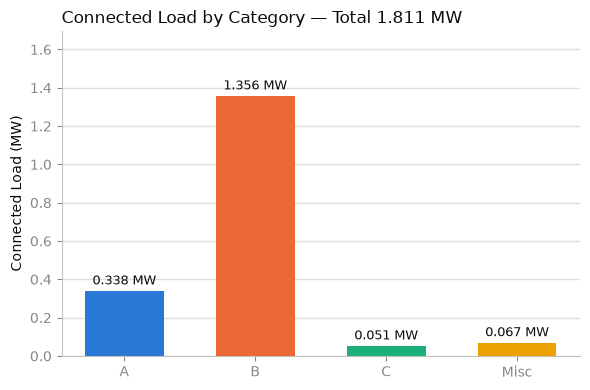

In [14]:
# --- Chart 1: Connected load by category ---
by_cat = result["by_category"].copy()  # copy(): work on a copy of the by_category table so we can add chart-specific columns
by_cat["mw"] = by_cat["connected_load_w_subtotal"] / 1_000_000  # compute: convert W to MW for a cleaner y-axis
by_cat["color"] = by_cat["category"].map(CATEGORY_COLORS)  # map(): look up each row's bar color from the fixed CATEGORY_COLORS dict

fig, ax = plt.subplots(figsize=(6, 4))  # subplots(): create a new figure and axes to draw the chart on
bars = ax.bar(by_cat["category"], by_cat["mw"], color=by_cat["color"], width=0.6)  # bar(): draw one vertical bar per category

# Direct labels on each bar (clearer than a legend for only 4 bars)
for bar, mw in zip(bars, by_cat["mw"]):  # zip(): pair each bar with its MW value, so we can label it
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.02,  # text(): draw the MW value just above each bar
            f"{mw:.3f} MW", ha="center", va="bottom", fontsize=9, color=TEXT_PRIMARY)

ax.set_ylabel("Connected Load (MW)")  # label the y-axis
ax.set_title(f"Connected Load by Category — Total {by_cat['mw'].sum():.3f} MW", loc="left", fontsize=12)  # set the chart title, including the grand total
ax.spines[["top", "right"]].set_visible(False)  # hide the top and right border lines, for a cleaner look
ax.spines[["left", "bottom"]].set_color(AXIS_INK)  # color the remaining border lines with our muted axis color
ax.yaxis.grid(True, color=GRIDLINE, linewidth=1, zorder=0)  # grid(): draw faint horizontal gridlines behind the bars
ax.set_axisbelow(True)  # keep the gridlines behind the bars, not drawn on top of them
ax.set_ylim(0, by_cat["mw"].max() * 1.25)  # set_ylim(): leave headroom above the tallest bar so its label isn't cut off
plt.tight_layout()  # tight_layout(): auto-adjust spacing so labels don't get clipped
plt.show()  # show(): render the chart in the notebook output

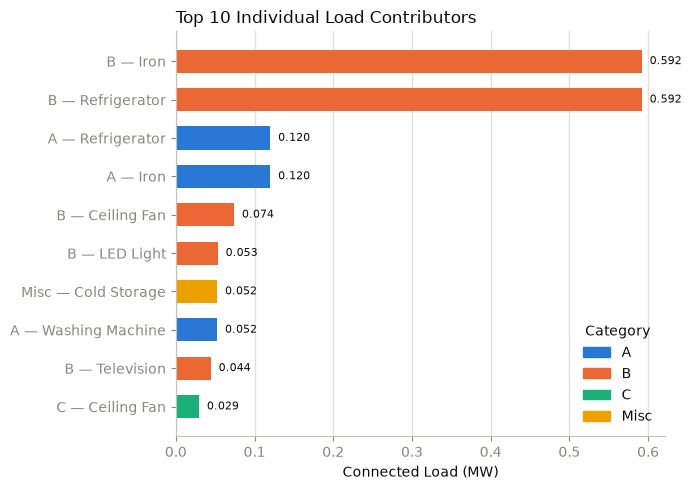

In [15]:
# --- Chart 2: Top individual load contributors, colored by category ---
top_n = 10  # how many of the largest load lines to show
top_lines = result["lines"].nlargest(top_n, "connected_load_w").copy()  # nlargest(): pick the top-N rows by connected_load_w
top_lines["mw"] = top_lines["connected_load_w"] / 1_000_000  # convert W to MW for the chart
top_lines["label"] = top_lines["category"] + " — " + top_lines["appliance"]  # build a combined "Category — Appliance" label for each bar
top_lines = top_lines.sort_values("mw")  # sort_values(): ascending order, so the largest ends up at the top of the horizontal bar chart
top_lines["color"] = top_lines["category"].map(CATEGORY_COLORS)  # map(): look up each bar's color from the fixed CATEGORY_COLORS dict

fig, ax = plt.subplots(figsize=(7, 5))  # subplots(): create a new figure and axes to draw the chart on
bars = ax.barh(top_lines["label"], top_lines["mw"], color=top_lines["color"], height=0.6)  # barh(): draw one horizontal bar per load line

for bar, mw in zip(bars, top_lines["mw"]):  # zip(): pair each bar with its MW value, so we can label it
    ax.text(bar.get_width() + 0.01, bar.get_y() + bar.get_height() / 2,  # text(): draw the MW value just past the end of each bar
            f"{mw:.3f}", va="center", fontsize=8, color=TEXT_PRIMARY)

ax.set_xlabel("Connected Load (MW)")  # label the x-axis
ax.set_title(f"Top {top_n} Individual Load Contributors", loc="left", fontsize=12)  # set the chart title
ax.spines[["top", "right"]].set_visible(False)  # hide the top and right border lines
ax.spines[["left", "bottom"]].set_color(AXIS_INK)  # color the remaining border lines
ax.xaxis.grid(True, color=GRIDLINE, linewidth=1, zorder=0)  # grid(): draw faint vertical gridlines behind the bars
ax.set_axisbelow(True)  # keep the gridlines behind the bars

# Legend for the category color coding
handles = [plt.Rectangle((0, 0), 1, 1, color=c) for c in CATEGORY_COLORS.values()]  # list comprehension: build one colored square per category, to use as legend swatches
ax.legend(handles, CATEGORY_COLORS.keys(), title="Category", loc="lower right", frameon=False)  # legend(): show the category color key

plt.tight_layout()  # tight_layout(): auto-adjust spacing so labels don't get clipped
plt.show()  # show(): render the chart in the notebook output

## 1.6 Summary

- **Total Connected Load: 1.81128 MW** across 1,480 households (Categories A/B/C) plus Misc./community loads — matches Annex-I exactly.
- Cold Storage and Category B lighting/fans are among the largest individual contributors (visible in the chart above) — worth keeping an eye on if those quantities get edited later.
- All three input tables (`household_categories`, `appliances`, `misc_loads`) are saved as CSV in `data/`, and export/import to a formatted, validated Excel template both work as a round trip.
- `compute_connected_load()` is the one function the Streamlit app's "Step 1" page will call — on the defaults, on hand-edited table values, or on a re-uploaded Excel file — with no changes needed to the function itself.

**Next notebook (Step 2):** turn this connected load into a full **8,760-hour annual load profile**, using the day-type patterns (season/weekday/weekend/holiday/festival) from Annex-II and Annex-III — including the fix to the mid-Aug–mid-Oct calendar mapping bug agreed earlier.